In [2]:
!pip -q install -U importlib_resources protobuf tensorflow-datasets tensorflow-metadata

In [3]:
import gc
import time
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, optimizers, regularizers
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

tf.random.set_seed(42)
np.random.seed(42)

IMG_SIZE_SMALL = 160   # used for Tasks 1-5, 7 (many from-scratch training runs)
IMG_SIZE_FULL = 224    # used for Tasks 6, 8 (transfer learning + final model)
BATCH_SMALL = 16
BATCH_FULL = 32
NUM_CLASSES = 2  # Cat vs Dog

(ds_train, ds_val, ds_test), ds_info = tfds.load(
    "oxford_iiit_pet",
    split=["train[:70%]", "train[70%:85%]", "train[85%:]"],
    with_info=True,
    as_supervised=False,
)

def make_preprocess(img_size):
    def preprocess(example):
        image = tf.image.resize(example["image"], (img_size, img_size))
        image = tf.keras.applications.mobilenet_v2.preprocess_input(tf.cast(image, tf.float32))
        return image, example["species"]  # species: 0 = Cat, 1 = Dog
    return preprocess

def make_pipeline(ds, img_size, shuffle=False, augment=False, batch_size=BATCH_SMALL):
    ds = ds.map(make_preprocess(img_size), num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000)
    if augment:
        aug = tf.keras.Sequential([layers.RandomFlip("horizontal"), layers.RandomRotation(0.05)])
        ds = ds.map(lambda x, y: (aug(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Light pipeline (160x160, batch 16) - Tasks 1-5, 7
train_ds_s = make_pipeline(ds_train, IMG_SIZE_SMALL, shuffle=True, augment=True, batch_size=BATCH_SMALL)
val_ds_s = make_pipeline(ds_val, IMG_SIZE_SMALL, batch_size=BATCH_SMALL)

# Full-resolution pipeline (224x224, batch 32) - Tasks 6, 8
train_ds_f = make_pipeline(ds_train, IMG_SIZE_FULL, shuffle=True, augment=True, batch_size=BATCH_FULL)
val_ds_f = make_pipeline(ds_val, IMG_SIZE_FULL, batch_size=BATCH_FULL)
test_ds_f = make_pipeline(ds_test, IMG_SIZE_FULL, batch_size=BATCH_FULL)

def build_model(initializer, img_size, dropout=0.0, l2_reg=0.0, use_bn=True, weights=None):
    reg = regularizers.l2(l2_reg) if l2_reg > 0 else None
    base = tf.keras.applications.MobileNetV2(
        input_shape=(img_size, img_size, 3), include_top=False, weights=weights, pooling="avg"
    )
    x = base.output
    if use_bn:
        x = layers.BatchNormalization()(x)
    if dropout > 0:
        x = layers.Dropout(dropout)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax", kernel_initializer=initializer, kernel_regularizer=reg)(x)
    return base, models.Model(base.input, out)

def free_memory(*objs):
    """Delete given objects, clear the Keras backend graph, and force a GC pass.
    Call this after every model you finish training in a loop."""
    for o in objs:
        del o
    tf.keras.backend.clear_session()
    gc.collect()

print("Data pipelines ready:", ds_info.splits)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.ZA50QB_4.0.0/oxford_iiit_pet-train.tfrecord-[0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.ZA50QB_4.0.0/oxford_iiit_pet-test.tfrecord-[0-9…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
Data pipelines ready: {'train': <SplitInfo num_examples=3680, num_shards=4>, 'test': <SplitInfo num_examples=3669, num_shards=4>}


Task 1

Training with zeros initialization
Epoch 1/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 94s 207ms/step - accuracy: 0.6106 - loss: 0.6857 - val_accuracy: 0.6957 - val_loss: 0.6790
Epoch 2/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 21s 113ms/step - accuracy: 0.6720 - loss: 0.6544 - val_accuracy: 0.6957 - val_loss: 0.6169
Epoch 3/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 40s 111ms/step - accuracy: 0.6561 - loss: 0.6439 - val_accuracy: 0.6957 - val_loss: 0.6496
Epoch 4/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 21s 117ms/step - accuracy: 0.6634 - loss: 0.6250 - val_accuracy: 0.6957 - val_loss: 0.6184
Epoch 5/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 40s 111ms/step - accuracy: 0.6689 - loss: 0.6376 - val_accuracy: 0.6957 - val_loss: 0.6750
Training with random_normal initialization
Epoch 1/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 73s 163ms/step - accuracy: 0.6277 - loss: 0.8961 - val_accuracy: 0.6957 - val_loss: 0.6155
Epoch 2/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 21s 118ms/step - accuracy: 0.6363 - loss: 0.7038 - val_accuracy: 0.6957 - val_loss: 0.6423
Epoch 3/5
16

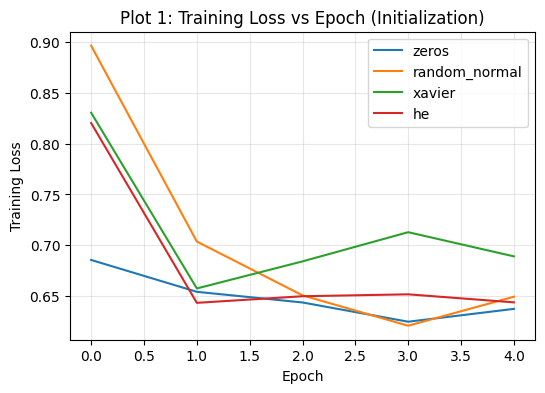

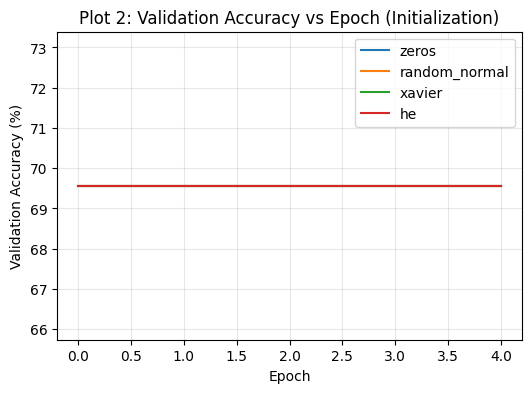

In [4]:
initializers_to_test = {
    "zeros": tf.keras.initializers.Zeros(),
    "random_normal": tf.keras.initializers.RandomNormal(stddev=0.05),
    "xavier": tf.keras.initializers.GlorotUniform(),
    "he": tf.keras.initializers.HeNormal(),
}
EPOCHS = 5
init_history = {}

for name, init in initializers_to_test.items():
    print(f"Training with {name} initialization")
    tf.keras.backend.clear_session()
    _, model = build_model(init, IMG_SIZE_SMALL)
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    init_history[name] = model.fit(train_ds_s, validation_data=val_ds_s, epochs=EPOCHS, verbose=1).history
    free_memory(model)

plt.figure(figsize=(6, 4))
for name, h in init_history.items():
    plt.plot(h["loss"], label=name)
plt.xlabel("Epoch"); plt.ylabel("Training Loss")
plt.title("Plot 1: Training Loss vs Epoch (Initialization)")
plt.legend(); plt.grid(alpha=0.3); plt.show(); plt.close('all')

plt.figure(figsize=(6, 4))
for name, h in init_history.items():
    plt.plot([a * 100 for a in h["val_accuracy"]], label=name)
plt.xlabel("Epoch"); plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 2: Validation Accuracy vs Epoch (Initialization)")
plt.legend(); plt.grid(alpha=0.3); plt.show(); plt.close('all')

Task 2

Training with no_regularization
Epoch 1/8
161/161 ━━━━━━━━━━━━━━━━━━━━ 72s 164ms/step - accuracy: 0.6541 - loss: 0.6937 - val_accuracy: 0.6957 - val_loss: 0.6885
Epoch 2/8
161/161 ━━━━━━━━━━━━━━━━━━━━ 21s 119ms/step - accuracy: 0.6770 - loss: 0.6214 - val_accuracy: 0.6957 - val_loss: 0.6833
Epoch 3/8
161/161 ━━━━━━━━━━━━━━━━━━━━ 21s 112ms/step - accuracy: 0.6887 - loss: 0.5938 - val_accuracy: 0.6957 - val_loss: 0.6746
Epoch 4/8
161/161 ━━━━━━━━━━━━━━━━━━━━ 40s 111ms/step - accuracy: 0.6972 - loss: 0.5792 - val_accuracy: 0.6957 - val_loss: 0.6515
Epoch 5/8
161/161 ━━━━━━━━━━━━━━━━━━━━ 21s 112ms/step - accuracy: 0.6976 - loss: 0.5673 - val_accuracy: 0.3043 - val_loss: 0.6966
Epoch 6/8
161/161 ━━━━━━━━━━━━━━━━━━━━ 41s 119ms/step - accuracy: 0.7143 - loss: 0.5518 - val_accuracy: 0.6957 - val_loss: 0.6572
Epoch 7/8
161/161 ━━━━━━━━━━━━━━━━━━━━ 20s 112ms/step - accuracy: 0.7170 - loss: 0.5482 - val_accuracy: 0.3043 - val_loss: 0.7891
Epoch 8/8
161/161 ━━━━━━━━━━━━━━━━━━━━ 21s 117ms/step - ac

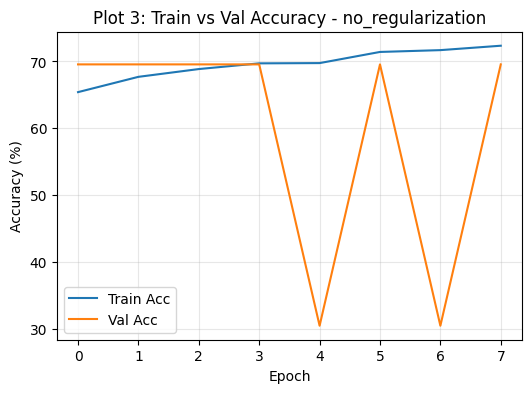

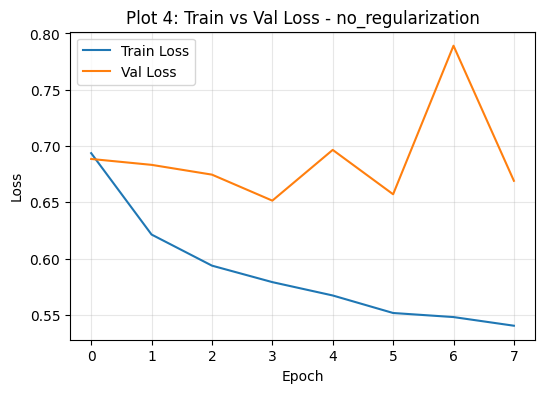

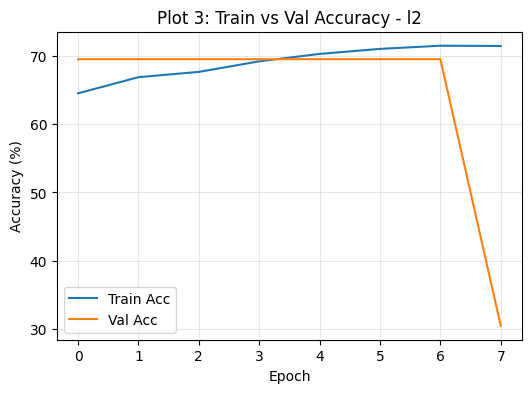

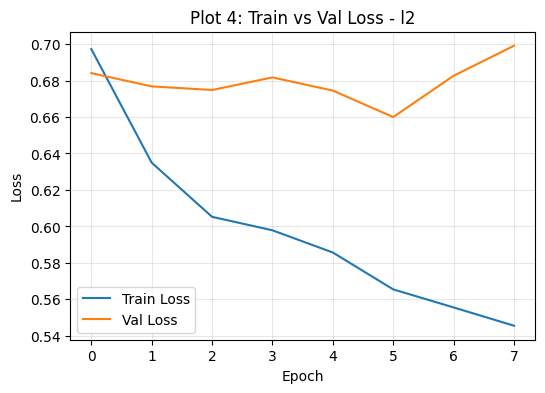

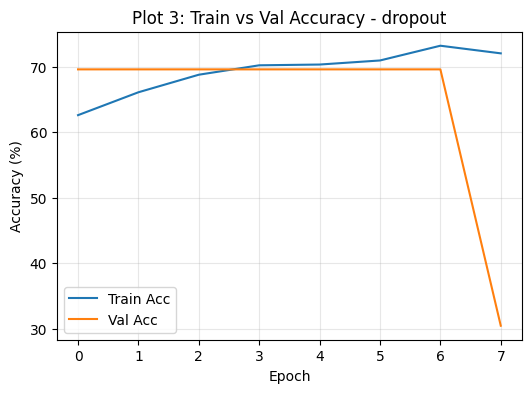

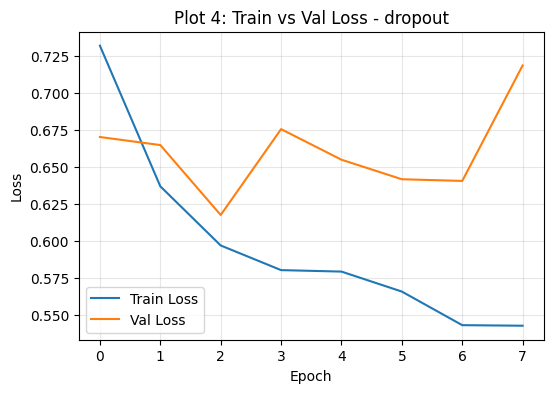

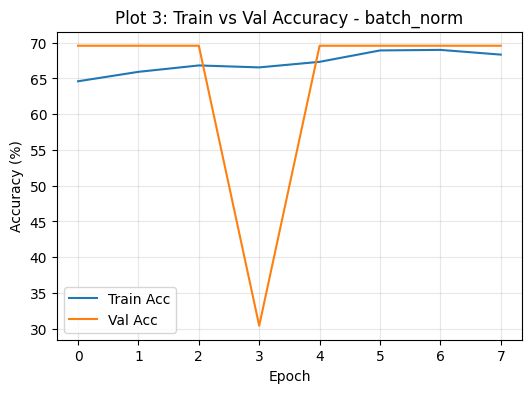

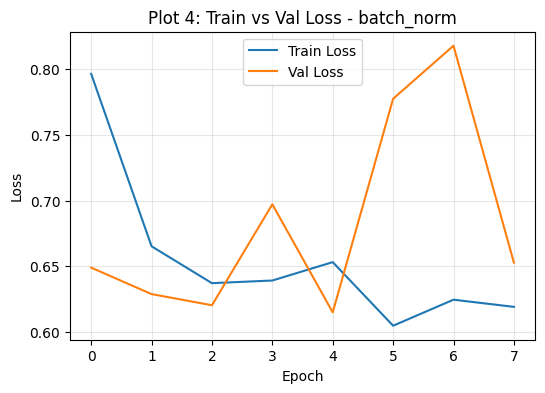

In [5]:
reg_configs = {
    "no_regularization": dict(dropout=0.0, l2_reg=0.0, use_bn=False),
    "l2": dict(dropout=0.0, l2_reg=1e-3, use_bn=False),
    "dropout": dict(dropout=0.5, l2_reg=0.0, use_bn=False),
    "batch_norm": dict(dropout=0.0, l2_reg=0.0, use_bn=True),
}
EPOCHS = 8
reg_history = {}

for name, cfg in reg_configs.items():
    print(f"Training with {name}")
    tf.keras.backend.clear_session()
    _, model = build_model(tf.keras.initializers.HeNormal(), IMG_SIZE_SMALL, **cfg)
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    reg_history[name] = model.fit(train_ds_s, validation_data=val_ds_s, epochs=EPOCHS, verbose=1).history
    free_memory(model)

for name, h in reg_history.items():
    plt.figure(figsize=(6, 4))
    plt.plot([a * 100 for a in h["accuracy"]], label="Train Acc")
    plt.plot([a * 100 for a in h["val_accuracy"]], label="Val Acc")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)")
    plt.title(f"Plot 3: Train vs Val Accuracy - {name}")
    plt.legend(); plt.grid(alpha=0.3); plt.show(); plt.close('all')

    plt.figure(figsize=(6, 4))
    plt.plot(h["loss"], label="Train Loss")
    plt.plot(h["val_loss"], label="Val Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title(f"Plot 4: Train vs Val Loss - {name}")
    plt.legend(); plt.grid(alpha=0.3); plt.show(); plt.close('all')

Task 3

mu_B = 5.0  var_B = 5.0
x_hat = [-1.34164079 -0.4472136   0.4472136   1.34164079]
y = [-1.34164079 -0.4472136   0.4472136   1.34164079]
Training With_BN
Epoch 1/8
161/161 ━━━━━━━━━━━━━━━━━━━━ 72s 163ms/step - accuracy: 0.6293 - loss: 0.8615 - val_accuracy: 0.6957 - val_loss: 0.6173
Epoch 2/8
161/161 ━━━━━━━━━━━━━━━━━━━━ 20s 110ms/step - accuracy: 0.6646 - loss: 0.6525 - val_accuracy: 0.6957 - val_loss: 0.6153
Epoch 3/8
161/161 ━━━━━━━━━━━━━━━━━━━━ 21s 112ms/step - accuracy: 0.6669 - loss: 0.6272 - val_accuracy: 0.6957 - val_loss: 0.6233
Epoch 4/8
161/161 ━━━━━━━━━━━━━━━━━━━━ 22s 125ms/step - accuracy: 0.6724 - loss: 0.6208 - val_accuracy: 0.6957 - val_loss: 0.6778
Epoch 5/8
161/161 ━━━━━━━━━━━━━━━━━━━━ 40s 112ms/step - accuracy: 0.6495 - loss: 0.6410 - val_accuracy: 0.6957 - val_loss: 0.6283
Epoch 6/8
161/161 ━━━━━━━━━━━━━━━━━━━━ 22s 125ms/step - accuracy: 0.6797 - loss: 0.6251 - val_accuracy: 0.6957 - val_loss: 0.6254
Epoch 7/8
161/161 ━━━━━━━━━━━━━━━━━━━━ 21s 116ms/step - accuracy: 0

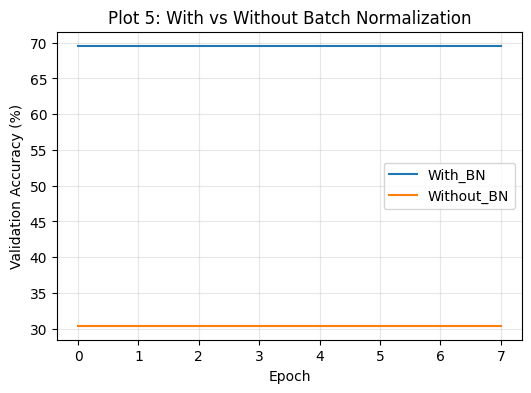

In [6]:
x = np.array([2.0, 4.0, 6.0, 8.0])
mu, var, eps = x.mean(), x.var(), 1e-8
x_hat = (x - mu) / np.sqrt(var + eps)
gamma, beta = 1.0, 0.0
y = gamma * x_hat + beta
print("mu_B =", mu, " var_B =", var)
print("x_hat =", x_hat)
print("y =", y)

EPOCHS = 8
bn_history = {}
for name, use_bn in {"With_BN": True, "Without_BN": False}.items():
    print(f"Training {name}")
    tf.keras.backend.clear_session()
    _, model = build_model(tf.keras.initializers.HeNormal(), IMG_SIZE_SMALL, use_bn=use_bn)
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    bn_history[name] = model.fit(train_ds_s, validation_data=val_ds_s, epochs=EPOCHS, verbose=1).history
    free_memory(model)

plt.figure(figsize=(6, 4))
for name, h in bn_history.items():
    plt.plot([a * 100 for a in h["val_accuracy"]], label=name)
plt.xlabel("Epoch"); plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 5: With vs Without Batch Normalization")
plt.legend(); plt.grid(alpha=0.3); plt.show(); plt.close('all')